# Model Traininig 
1. data cleaning 
2. preprocessing 
3. model training 
4. validation 

### Imports

In [53]:
import pandas as pd 
import numpy as np 

# time 
import time 

# visualization 
import seaborn as sns 
import matplotlib.pyplot as plt 

# preprocessing 
from sklearn.impute import SimpleImputer   # missing values 
from sklearn.preprocessing import LabelEncoder , OrdinalEncoder , OneHotEncoder 

# scalling 
from sklearn.preprocessing import StandardScaler  

# spliting data 
from sklearn.model_selection import train_test_split 

# models 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 

# pipeilne 
from sklearn.pipeline import Pipeline

# column transformer 
from sklearn.compose import ColumnTransformer 

# parameter tunning 
import  optuna 

# evaluation 
from sklearn.metrics import roc_auc_score , ConfusionMatrixDisplay, classification_report , confusion_matrix, precision_score , recall_score

### Load data 

In [54]:
df = pd.read_csv('..\Data\customer_churn_dataset-testing-master.csv')

In [55]:
df.head() 


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [57]:
df.describe() 

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


### Data Cleaning 

In [58]:
# Droping customer Id 
df.drop(columns=['CustomerID'] , inplace= True )

In [59]:
df.head() 

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [60]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

In [61]:
numarical_columns = [  'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay',   'Total Spend']

categorical_columns = ['Gender','Subscription Type','Contract Length' ]

<Axes: >

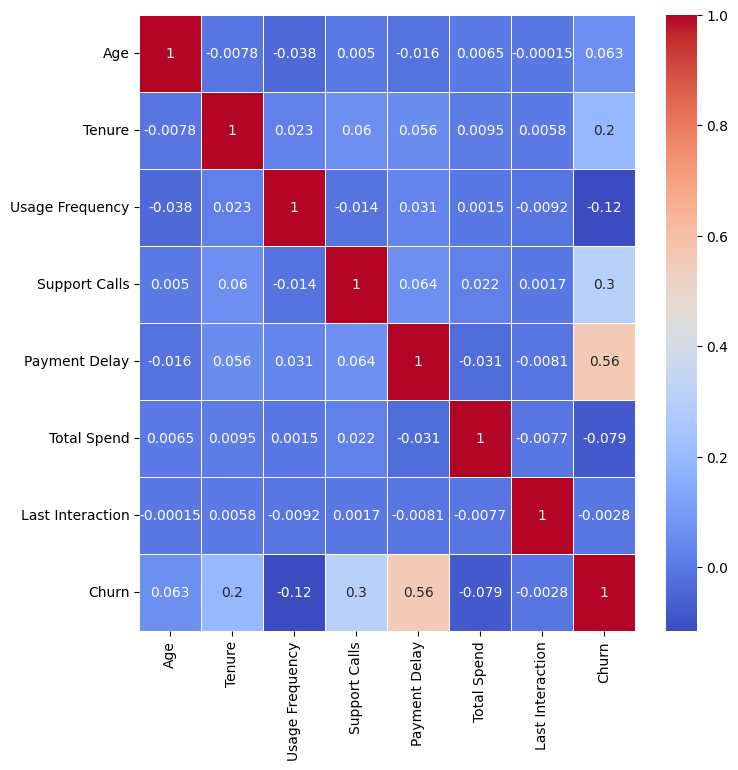

In [62]:
## ploting relationship between features 
corr = df.corr(numeric_only=True )
plt.figure(figsize=(8,8))
sns.heatmap(data= corr  , annot=True , cmap='coolwarm' ,linewidths=0.5 )

In [63]:
corr = df.corr(numeric_only=True)
corr['Churn'].sort_values(ascending=False)

Churn               1.000000
Payment Delay       0.557386
Support Calls       0.304631
Tenure              0.195327
Age                 0.063457
Last Interaction   -0.002818
Total Spend        -0.078867
Usage Frequency    -0.115098
Name: Churn, dtype: float64

Observation :- 
   1. we are seeing that the columns last interaction , Age , And Usage Frequency are to week 
   2. these feature are with less muliticoliniarly related to other features 
   3. also less contributting to the dependent features 

removing age and Last Interaction becouse there are weak and useless columns for churn  

In [64]:
## removing age and last interaction columns  

df.drop(columns=['Age' , "Last Interaction"] , inplace= True )

In [65]:
df.head() 

,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Churn
0,Female,25,14,4,27,Basic,Monthly,598,1
1,Female,28,28,7,13,Standard,Monthly,584,0
2,Male,27,10,2,29,Premium,Annual,757,0
3,Male,9,12,5,17,Premium,Quarterly,232,0
4,Female,58,24,9,2,Standard,Annual,533,0


### split data 

In [66]:
df.head() 

,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Churn
0,Female,25,14,4,27,Basic,Monthly,598,1
1,Female,28,28,7,13,Standard,Monthly,584,0
2,Male,27,10,2,29,Premium,Annual,757,0
3,Male,9,12,5,17,Premium,Quarterly,232,0
4,Female,58,24,9,2,Standard,Annual,533,0


In [67]:
X = df.iloc[ :, :-1]
y = df.iloc[: , -1 ]

In [68]:
#  train and test 
X_train,X_test ,y_train,y_test = train_test_split(X,y , random_state=32 , test_size=0.2)


# train and val 
X_train , X_val , y_train  , y_val = train_test_split(X_train,y_train , random_state=42 , test_size=0.2 )
y_train.shape

(41199,)

### Preprocessing 
building pipeline for the feature to convert them into numaric values  
columns :-  Gender , Subscription Type , Contract Lenght 

#### Pipelilnes 

In [69]:
## Gender 

gender_pipe = Pipeline( steps =[ 
    ('OHT' , OneHotEncoder(handle_unknown='ignore')) 
])

In [70]:
# Subscription Type :- ordinal data so use ordinal encoding 

subscription_pipe = Pipeline(steps=[
    ('sub_type_order', OrdinalEncoder(
        categories=[['Basic', 'Standard', 'Premium']]
    ))
])

In [71]:
# 	Contract Length

contrat_len_pipe = Pipeline( steps = [
    ( 'contrac_encode' , OrdinalEncoder(categories=[['Monthly', 'Quarterly', 'Annual']]))
])


In [72]:
# Scaling pipelilne 

scaler_pipe  = Pipeline(steps= [ 
    ( 'Scaler' , StandardScaler() )
])

#### column Transformer 

In [73]:
X_train.columns

Index(['Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
       'Subscription Type', 'Contract Length', 'Total Spend'],
      dtype='object')

In [74]:
num_columns = ['Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend']
preprocessor = ColumnTransformer( transformers=  [ 
    ('gender_pipe' , gender_pipe , ['Gender']) , 
    ('subscription_pipe' , subscription_pipe , ['Subscription Type'] ) , 
    ('contrat_len_pipe' , contrat_len_pipe,  ['Contract Length']  ) , 
    ('scaler' , scaler_pipe , num_columns)
] , remainder ="passthrough" 
)
preprocessor

,transformers,"[('gender_pipe', ...), ('subscription_pipe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


#### Model Chossing with best parameters 

Note :- 
1. In churn prediction we need to Reduce the values of the False negative which actually Cause the comapny 
2. If churn is true and predicting it is not a churn 
3. Minimize the Recall 

#### Random Forest 

In [75]:
def objective(trial):

    r_params = {
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.05),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'max_depth': trial.suggest_int('max_depth', 10, 40, step=5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50)
    }

    random_forest_pipe =  Pipeline(steps = [
            ('Preprocessor' , preprocessor) , 
            ('RandomForestClassifier' , RandomForestClassifier(**r_params, n_jobs=-1, random_state=42))
            ])

    random_forest_pipe.fit(X_train, y_train)
    y_pred = random_forest_pipe.predict_proba(X_val)[: , 1]

    return roc_auc_score(y_val, y_pred)

In [76]:

study = optuna.create_study(direction='maximize')

[I 2026-04-17 12:48:34,408] A new study created in memory with name: no-name-194d664a-854b-462d-93cc-1d70c8b98527


In [77]:
# optimize 
s = time.time() 
study.optimize(objective , n_trials= 10 )
print(f"Training time : {time.time() - s}")

[I 2026-04-17 12:48:34,852] Trial 0 finished with value: 0.985548749067509 and parameters: {'bootstrap': True, 'ccp_alpha': 0.022711096620942985, 'criterion': 'log_loss', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 100}. Best is trial 0 with value: 0.985548749067509.
[I 2026-04-17 12:48:41,197] Trial 1 finished with value: 0.9845618450698765 and parameters: {'bootstrap': True, 'ccp_alpha': 0.010725738504629673, 'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 500}. Best is trial 0 with value: 0.985548749067509.
[I 2026-04-17 12:48:45,751] Trial 2 finished with value: 0.9830898850376919 and parameters: {'bootstrap': True, 'ccp_alpha': 0.02790987612297785, 'criterion': 'entropy', 'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 10, 'min_samples_split': 3, 'n_estimators': 250}. Best is trial 0 with value: 0.985548749067509.
[I 2026-04-17 12:4

Training time : 47.537222146987915


In [78]:
r_params = study.best_params
r_params

{'bootstrap': True,
 'ccp_alpha': 0.022282912054836942,
 'criterion': 'entropy',
 'max_depth': 20,
 'max_features': 'log2',
 'min_samples_leaf': 10,
 'min_samples_split': 3,
 'n_estimators': 300}

In [79]:
study.best_value

0.9857844222716189

##### Training and testing model on best parameters 

In [80]:
threshold  = 0.5 
random_forest = Pipeline(steps = [ 
    ('preprocessor' , preprocessor ) , 
    ( 'Random_Forest' , RandomForestClassifier(**r_params , n_jobs=-1 , random_state=42)) , 
    ]  , )

random_forest.fit(X_train,y_train) 
y_pred = random_forest.predict_proba(X_test)[:, 1]

print(f'roc_auc_score: { roc_auc_score(y_test,y_pred)  }')

# threshold values 
y_pred= (y_pred > threshold ).astype(int)

print(f"precision_score :{ precision_score(y_test,y_pred )}")
print(f"Recall_score : {recall_score(y_test,y_pred )}")
cm = confusion_matrix(y_test, y_pred)


roc_auc_score: 0.9863695191193125
precision_score :0.9635943882081336
Recall_score : 0.8918474687705457


In [81]:
### precisoin recal values with different threshold 
y_prob = random_forest.predict_proba(X_val)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_temp = (y_prob > t).astype(int)   # ✅ use new variable
    
    print(f"Threshold: {t}")
    print(f"Precision: {precision_score(y_val, y_temp)}")
    print(f"Recall: {recall_score(y_val, y_temp)}")
    print("-"*30)

Threshold: 0.3
Precision: 0.843074743181013
Recall: 0.9784172661870504
------------------------------
Threshold: 0.4
Precision: 0.8848298404153048
Recall: 0.9459403905447071
------------------------------
Threshold: 0.5
Precision: 0.9666815742397138
Recall: 0.8885919835560123
------------------------------
Threshold: 0.6
Precision: 0.9815068493150685
Recall: 0.8836587872559095
------------------------------
Threshold: 0.7
Precision: 1.0
Recall: 0.8731757451181912
------------------------------


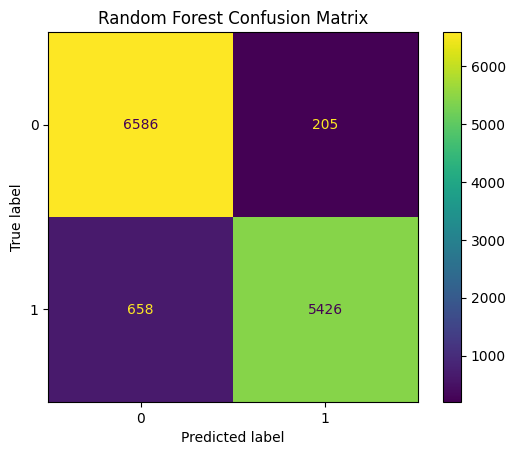

In [82]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

#### Xgboost Model 

In [83]:
print(XGBClassifier().get_params() )

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [84]:
def objective(trial) : 
    xgb_params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",

        # Core parameters
        "n_estimators": trial.suggest_int("n_estimators", 100, 500 , step = 50 ),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),

        # Regularization
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),

        # Tree-specific
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),

        # Sampling
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

        # Imbalance handling (important for churn)
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 10),

        # Performance
        "random_state": 42,
        "n_jobs": -1
    }
 
    xgb_pipe = Pipeline( steps= [ 
        ( 'preprocessor' , preprocessor ) , 
        ('xgb' , XGBClassifier(**xgb_params ) )
        ] ) 
    xgb_pipe.fit(X_train , y_train) 
    y_pred = xgb_pipe.predict_proba(X_val)[:, 1]

    Accuracy = roc_auc_score(y_val, y_pred ) 

    return Accuracy 

In [85]:
study = optuna.create_study(direction= 'maximize') 

[I 2026-04-17 12:49:28,431] A new study created in memory with name: no-name-c2c7874a-61f3-4cd8-8aad-da7d40ed6f6a


In [86]:
s = time.time() 
study.optimize(objective , n_trials= 10 )
print(f"Training time : {time.time() - s}")

[I 2026-04-17 12:49:29,974] Trial 0 finished with value: 0.9974352220155798 and parameters: {'n_estimators': 350, 'max_depth': 9, 'learning_rate': 0.2762085371335088, 'reg_alpha': 0.1170916007487739, 'reg_lambda': 0.2551887467187235, 'min_child_weight': 10, 'gamma': 4.953485054022971, 'subsample': 0.7793546668466527, 'colsample_bytree': 0.8175201766765361, 'scale_pos_weight': 2.7901554206905863}. Best is trial 0 with value: 0.9974352220155798.
[I 2026-04-17 12:49:30,866] Trial 1 finished with value: 0.9974355056630211 and parameters: {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05438212723122542, 'reg_alpha': 0.39723243188629853, 'reg_lambda': 0.8092526280874371, 'min_child_weight': 7, 'gamma': 3.124833069164943, 'subsample': 0.9546494109039654, 'colsample_bytree': 0.9769992903879914, 'scale_pos_weight': 5.010181035779393}. Best is trial 1 with value: 0.9974355056630211.
[I 2026-04-17 12:49:32,034] Trial 2 finished with value: 0.9972688155166496 and parameters: {'n_estimato

Training time : 16.75881052017212


In [87]:
study.best_value

0.9974355056630211

In [88]:
xgb_params = study.best_params

In [89]:
## Train 
xgb_pipe = Pipeline( steps= [ 
        ( 'preprocessor' , preprocessor ) , 
        ('xgb' , XGBClassifier(**xgb_params ) )
        ] ) 

xgb_pipe.fit(X_train,y_train) 
y_pred = xgb_pipe.predict_proba(X_test)[:, 1]

print(f'Accuracy : {roc_auc_score(y_test,y_pred)} ')

y_pred= (y_pred > threshold ).astype(int)
print(f'precission : {precision_score(y_test,y_pred)}')
print(f'Recall: { recall_score(y_test, y_pred )}' ) 

cm = confusion_matrix(y_test , y_pred )

Accuracy : 0.9974214504036214 
precission : 0.9344186760866227
Recall: 1.0


In [90]:
# precisoin recall llwith different threshold 
y_prob = xgb_pipe.predict_proba(X_val)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_temp = (y_prob > t).astype(int)   # ✅ use new variable
    
    print(f"Threshold: {t}")
    print(f"Precision: {precision_score(y_val, y_temp)}")
    print(f"Recall: {recall_score(y_val, y_temp)}")
    print("-"*30)

Threshold: 0.3
Precision: 0.933960453062008
Recall: 1.0
------------------------------
Threshold: 0.4
Precision: 0.9352172241445598
Recall: 1.0
------------------------------
Threshold: 0.5
Precision: 0.9355645316407001
Recall: 0.9997944501541624
------------------------------
Threshold: 0.6
Precision: 0.9357074109720885
Recall: 0.9991778006166495
------------------------------
Threshold: 0.7
Precision: 0.9358752166377816
Recall: 0.998972250770812
------------------------------


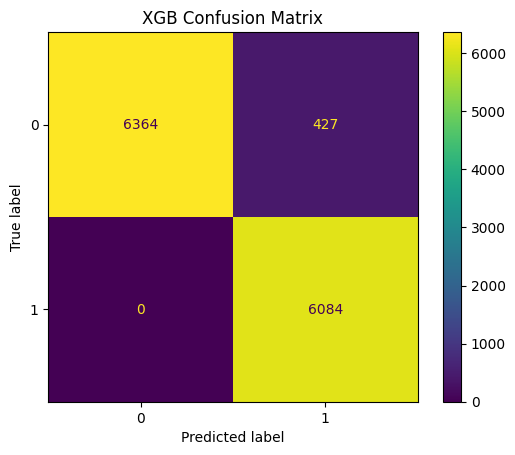

In [91]:
disp = ConfusionMatrixDisplay( confusion_matrix= cm ) 

disp.plot()
plt.title("XGB Confusion Matrix")
plt.show() 

Observations :- 
1. from abouve graph it show's that the model reduced the recall values to much 
2. XGBoost classifier is giving good values for churn prediction 

#### Light GBM 

In [92]:
def objective(trial) : 
    LGBM_params= { 
        "objective": "binary",
        "metric": "auc",

        # Core parameters
        "n_estimators": trial.suggest_int("n_estimators", 100, 500 , step = 50 ),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),

        # Tree complexity
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),

        # Regularization
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),

        # Sampling
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "force_row_wise" : True , 
        "force_row_wise" : True ,
        # Imbalance handling
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 10),
        # Speed
        "random_state": 42,
        "n_jobs": -1
    }

    LGBM_pipe = Pipeline(steps= [ 
        ( 'preprocessor' , preprocessor ), 
        ( 'Light_GBM'  , LGBMClassifier(**LGBM_params))
    ])

    LGBM_pipe.fit(X_train,y_train )
    y_pred = LGBM_pipe.predict_proba(X_val)[:, 1] 

    return  roc_auc_score(y_val,y_pred) 

In [93]:
study = optuna.create_study(direction='maximize') 

[I 2026-04-17 12:49:47,136] A new study created in memory with name: no-name-5055da05-c3d3-4c51-bf85-786035758bb9


In [94]:
LGBMClassifier().get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': None,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [95]:
s = time.time() 
study.optimize(objective , n_trials= 10 )
print(f"Training time : {time.time() - s}")

[LightGBM] [Info] Number of positive: 19544, number of negative: 21655
[LightGBM] [Info] Total Bins 401
[LightGBM] [Info] Number of data points in the train set: 41199, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474380 -> initscore=-0.102568
[LightGBM] [Info] Start training from score -0.102568
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-17 12:49:49,106] Trial 0 finished with value: 0.9973709664151974 and parameters: {'n_estimators': 350, 'learning_rate': 0.03265265926895886, 'num_leaves': 85, 'max_depth': 4, 'min_child_samples': 32, 'reg_alpha': 0.86855886718443, 'reg_lambda': 0.9132613495319161, 'subsample': 0.7859718649476228, 'colsample_bytree': 0.8869412351855808, 'scale_pos_weight': 7.529528875465502}. Best is trial 0 with value: 0.9973709664151974.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 19544, number of negative: 21655
[LightGBM] [Info] Total Bins 401
[LightGBM] [Info] Number of data points in the train set: 41199, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474380 -> initscore=-0.102568
[LightGBM] [Info] Start training from score -0.102568
[LightGBM] [Warning] No further splits with positive gain, best gain: 

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-17 12:49:53,836] Trial 1 finished with value: 0.9971313410567381 and parameters: {'n_estimators': 350, 'learning_rate': 0.028201310683902032, 'num_leaves': 51, 'max_depth': 12, 'min_child_samples': 45, 'reg_alpha': 0.292136935748871, 'reg_lambda': 0.6206542488006266, 'subsample': 0.7502232012549033, 'colsample_bytree': 0.5674131149071849, 'scale_pos_weight': 1.7531790927334274}. Best is trial 0 with value: 0.9973709664151974.


[LightGBM] [Info] Number of positive: 19544, number of negative: 21655
[LightGBM] [Info] Total Bins 401
[LightGBM] [Info] Number of data points in the train set: 41199, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474380 -> initscore=-0.102568
[LightGBM] [Info] Start training from score -0.102568
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-17 12:49:55,101] Trial 2 finished with value: 0.9972497165889316 and parameters: {'n_estimators': 350, 'learning_rate': 0.06403869090933702, 'num_leaves': 45, 'max_depth': 3, 'min_child_samples': 12, 'reg_alpha': 0.3158871217741577, 'reg_lambda': 0.35322164591000405, 'subsample': 0.8501327861536685, 'colsample_bytree': 0.9279696429121999, 'scale_pos_weight': 8.005228829041982}. Best is trial 0 with value: 0.9973709664151974.


[LightGBM] [Info] Number of positive: 19544, number of negative: 21655
[LightGBM] [Info] Total Bins 401
[LightGBM] [Info] Number of data points in the train set: 41199, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474380 -> initscore=-0.102568
[LightGBM] [Info] Start training from score -0.102568
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-17 12:49:58,920] Trial 3 finished with value: 0.9972994872599752 and parameters: {'n_estimators': 300, 'learning_rate': 0.12951419222094993, 'num_leaves': 62, 'max_depth': 9, 'min_child_samples': 20, 'reg_alpha': 0.2668843042126795, 'reg_lambda': 0.04029698357392708, 'subsample': 0.899631460601367, 'colsample_bytree': 0.8020230091431673, 'scale_pos_weight': 6.1678099457572575}. Best is trial 0 with value: 0.9973709664151974.


[LightGBM] [Info] Number of positive: 19544, number of negative: 21655
[LightGBM] [Info] Total Bins 401
[LightGBM] [Info] Number of data points in the train set: 41199, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474380 -> initscore=-0.102568
[LightGBM] [Info] Start training from score -0.102568
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-17 12:50:04,325] Trial 4 finished with value: 0.9973105684200176 and parameters: {'n_estimators': 450, 'learning_rate': 0.2618005588522972, 'num_leaves': 111, 'max_depth': 12, 'min_child_samples': 5, 'reg_alpha': 0.23575000191249207, 'reg_lambda': 0.0444318211002358, 'subsample': 0.5956342518974738, 'colsample_bytree': 0.6239938938486967, 'scale_pos_weight': 5.495691933522872}. Best is trial 0 with value: 0.9973709664151974.


[LightGBM] [Info] Number of positive: 19544, number of negative: 21655
[LightGBM] [Info] Total Bins 401
[LightGBM] [Info] Number of data points in the train set: 41199, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474380 -> initscore=-0.102568
[LightGBM] [Info] Start training from score -0.102568
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-17 12:50:05,741] Trial 5 finished with value: 0.9975059447776251 and parameters: {'n_estimators': 150, 'learning_rate': 0.0559437002523949, 'num_leaves': 95, 'max_depth': 6, 'min_child_samples': 44, 'reg_alpha': 0.09225370787598897, 'reg_lambda': 0.33899153065000676, 'subsample': 0.7299789726741439, 'colsample_bytree': 0.98774768743335, 'scale_pos_weight': 2.8801061258785223}. Best is trial 5 with value: 0.9975059447776251.


[LightGBM] [Info] Number of positive: 19544, number of negative: 21655
[LightGBM] [Info] Total Bins 401
[LightGBM] [Info] Number of data points in the train set: 41199, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474380 -> initscore=-0.102568
[LightGBM] [Info] Start training from score -0.102568
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-17 12:50:07,730] Trial 6 finished with value: 0.9972916964102524 and parameters: {'n_estimators': 200, 'learning_rate': 0.2484010866191495, 'num_leaves': 73, 'max_depth': 6, 'min_child_samples': 27, 'reg_alpha': 0.6609727159159138, 'reg_lambda': 0.6413097944684623, 'subsample': 0.9679917503472978, 'colsample_bytree': 0.6032031918056526, 'scale_pos_weight': 8.220756851448467}. Best is trial 5 with value: 0.9975059447776251.


[LightGBM] [Info] Number of positive: 19544, number of negative: 21655
[LightGBM] [Info] Total Bins 401
[LightGBM] [Info] Number of data points in the train set: 41199, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474380 -> initscore=-0.102568
[LightGBM] [Info] Start training from score -0.102568
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-17 12:50:09,072] Trial 7 finished with value: 0.9968709716154005 and parameters: {'n_estimators': 400, 'learning_rate': 0.029139946813973056, 'num_leaves': 98, 'max_depth': 3, 'min_child_samples': 49, 'reg_alpha': 0.41399391831021226, 'reg_lambda': 0.3438182940178115, 'subsample': 0.6321005152320802, 'colsample_bytree': 0.8628704475366166, 'scale_pos_weight': 5.2862542811541555}. Best is trial 5 with value: 0.9975059447776251.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-17 12:50:13,895] Trial 8 finished with value: 0.9972918476888878 and parameters: {'n_estimators': 400, 'learning_rate': 0.14503213506637522, 'num_leaves': 55, 'max_depth': 10, 'min_child_samples': 22, 'reg_alpha': 0.1975411240048749, 'reg_lambda': 0.057154446125357805, 'subsample': 0.5821699977835391, 'colsample_bytree': 0.6816758639958325, 'scale_pos_weight': 7.088501305569003}. Best is trial 5 with value: 0.9975059447776251.


[LightGBM] [Info] Number of positive: 19544, number of negative: 21655
[LightGBM] [Info] Total Bins 401
[LightGBM] [Info] Number of data points in the train set: 41199, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474380 -> initscore=-0.102568
[LightGBM] [Info] Start training from score -0.102568
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-17 12:50:14,617] Trial 9 finished with value: 0.997377017560613 and parameters: {'n_estimators': 200, 'learning_rate': 0.1593477924696803, 'num_leaves': 23, 'max_depth': 3, 'min_child_samples': 7, 'reg_alpha': 0.5823781693003557, 'reg_lambda': 0.8473497184737063, 'subsample': 0.9531985158696101, 'colsample_bytree': 0.7406663931211046, 'scale_pos_weight': 9.545751176611315}. Best is trial 5 with value: 0.9975059447776251.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [96]:
LGBM_params= study.best_params
study.best_value

0.9975059447776251

[LightGBM] [Info] Number of positive: 19544, number of negative: 21655
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000605 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 401
[LightGBM] [Info] Number of data points in the train set: 41199, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474380 -> initscore=-0.102568
[LightGBM] [Info] Start training from score -0.102568
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy Score : 0.9975059447776251
Precision Score : 0.9360677835547853
Recall Score : 0.9991778006166495


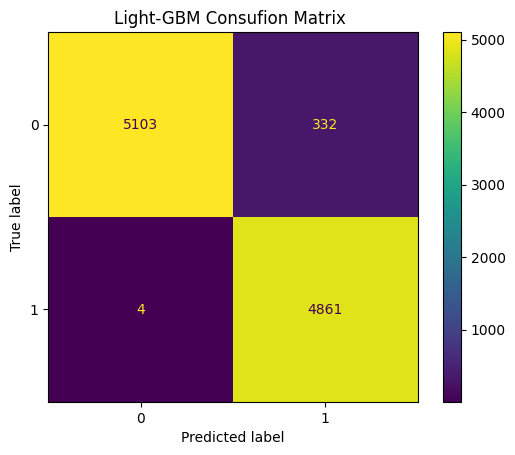

In [97]:
LGBM_pipe = Pipeline(steps= [ 
        ( 'preprocessor' , preprocessor ), 
        ( 'Light_GBM'  , LGBMClassifier(**LGBM_params))
    ])

LGBM_pipe.fit(X_train,y_train )
y_pred = LGBM_pipe.predict_proba(X_val)[:, 1]

print(f'Accuracy Score : {roc_auc_score(y_val, y_pred )}')

y_pred= (y_pred > threshold ).astype(int)
print(f'Precision Score : {precision_score(y_val, y_pred )}')
print(f'Recall Score : {recall_score (y_val, y_pred )}')

cm = confusion_matrix(y_val, y_pred) 
disp = ConfusionMatrixDisplay(confusion_matrix = cm ) 

disp.plot()  
plt.title('Light-GBM Consufion Matrix ')
plt.show() 

In [98]:
y_prob = LGBM_pipe.predict_proba(X_val)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_temp = (y_prob > t).astype(int)   # ✅ use new variable
    
    print(f"Threshold: {t}")
    print(f"Precision: {precision_score(y_val, y_temp)}")
    print(f"Recall: {recall_score(y_val, y_temp)}")
    print("-"*30)

Threshold: 0.3
Precision: 0.9353970390309556
Recall: 1.0
------------------------------
Threshold: 0.4
Precision: 0.9357321531652877
Recall: 0.9995889003083248
------------------------------
Threshold: 0.5
Precision: 0.9360677835547853
Recall: 0.9991778006166495
------------------------------
Threshold: 0.6
Precision: 0.9374034003091191
Recall: 0.997327852004111
------------------------------
Threshold: 0.7
Precision: 0.9433739677546206
Recall: 0.9862281603288797
------------------------------


d:\programing\AI-ML\Projects\Customer Churn prediction\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### final Decision :- Using LightGBM Model fot the project 
#### With  :- 
1. threshold 0.5  
2. all best parameters 
3. fast traininig 
4. good for large dataset 